# Magspec objective tuning

Exploratory notebook for organizing per-shot lineouts across **multiple scans** and ranking them by a user-defined scalar score. The output is a waterfall plot in which the y-axis is the score rather than shot or bin index, which makes it easier to see how the spectral shape varies with whatever quantity you're tuning for.

Walkthrough:

1. Pick a list of scans and the magspec device to load.
2. For every shot across all those scans, run the `LineAnalyzer` and pull the energy-axis lineout out of `result.line_data`.
3. Define a scoring function that maps a lineout to a single scalar.
4. Sort shots by score and render a waterfall.

This notebook is intentionally low-ceremony. The scoring function is the variable you'll iterate on. If a particular score stabilises into something you want in production, the right home for it is a small extension to `Array1DScanAnalyzer.waterfall_sort_key` (single-scan) rather than this notebook.

### Folder-vs-stem note

The device used here is `U_BCaveMagSpec-interpSpec`, whose data folder uses that full name but whose per-shot files are named `Scan<NNN>_U_BCaveMagSpec_<shot>.<ext>` — i.e., the folder name and the in-filename stem differ. We pass `device_file_stem="U_BCaveMagSpec"` to `ScanPaths.build_device_file_map` so file resolution works.

In [1]:
from geecs_data_utils.scan_data import ScanPaths
from image_analysis.offline_analyzers.line_analyzer import LineAnalyzer

from geecs_data_utils.config_roots import image_analysis_config
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
)
logging.getLogger("image_analysis").setLevel(logging.ERROR)
logging.getLogger("geecs_data_utils").setLevel(logging.ERROR)
image_analysis_config.set_base_dir(ScanPaths.paths_config.image_analysis_configs_path)

PosixPath('/Users/samuelbarber/Desktop/Code/Github_repos/GEECS-Plugins-Configs/image_analysis_configs')

## Configure the scans, the device, and the analyzer

Edit the cell below to point at the scans of interest. `DEVICE_FOLDER` is the on-disk subfolder name; `DEVICE_FILE_STEM` is the token used inside the per-shot filenames. They differ for `U_BCaveMagSpec-interpSpec`. `CAMERA_CONFIG_NAME` is the name (without extension) of the `Line1DConfig` YAML in your `image_analysis_configs` repo that drives `LineAnalyzer`'s preprocessing pipeline.

In [2]:
# --- which scans to combine ---
EXPERIMENT = "Undulator"
YEAR, MONTH, DAY = 2026, 5, 1
SCAN_NUMBERS = [1]  # arbitrary; iterate freely
SCAN_NUMBERS = range(1, 21)

# --- device naming ---
# Folder on disk:        .../ScanNNN/U_BCaveMagSpec-interpSpec/
# Per-shot filename:     ScanNNN_U_BCaveMagSpec_<shot>.<ext>
DEVICE_FOLDER = "U_BCaveMagSpec-interpSpec"
DEVICE_FILE_STEM = "U_BCaveMagSpec"
FILE_TAIL = ".txt"  # or ".png", ".csv" — inspect the folder if unsure

# --- analyzer config ---
# Name of the camera config YAML (without the .yaml extension)
# living in the image_analysis_configs repo.
CAMERA_CONFIG_NAME = "U_BCaveMagSpec-interpSpec"

Instantiate the `LineAnalyzer` once and reuse it for every shot. Per-shot processing flows through `analyze_image_file(path)` which calls `load_image` then `analyze_image`, returning an `ImageAnalyzerResult` whose `line_data` is an Nx2 array (column 0 = x-axis, column 1 = signal).

In [3]:
analyzer = LineAnalyzer(line_config_name=CAMERA_CONFIG_NAME)

## Load lineouts across all scans

We deliberately skip `ScanData` here — we don't need the scalar DataFrame for this workflow and the s-file load adds noticeable overhead when iterating across many scans. `ScanPaths.build_device_file_map` gives `{shot_number: file_path}` from a single `iterdir()`, and accepts the new `device_file_stem` kwarg so the folder ≠ filename-stem case resolves correctly.

If you _do_ want the scalar DataFrame (e.g., to colour the waterfall by laser energy or charge from the s-file), use `ScanData.from_date(..., stem_override={DEVICE_FOLDER: DEVICE_FILE_STEM})` instead. That populates the `<device>_expected_path` column correctly for this device too.

In [5]:
import time
import numpy as np
from dataclasses import dataclass
from pathlib import Path
from typing import Optional
from concurrent.futures import ThreadPoolExecutor


@dataclass
class ShotRecord:
    """ShotRecord."""

    scan_number: int
    shot_number: int
    path: Path
    x_axis: np.ndarray
    lineout: np.ndarray


def xy_from_result(result):
    """Pull (x, y) from a Standard1DAnalyzer / LineAnalyzer result."""
    ld = result.line_data
    if ld is None:
        return None, None
    arr = np.asarray(ld)
    if arr.ndim != 2 or arr.shape[1] < 2 or arr.shape[0] == 0:
        return None, None
    return arr[:, 0], arr[:, 1]


# --- build the work list (cheap; just file enumeration) ---
t_enum_start = time.perf_counter()
work = []
for scan_number in SCAN_NUMBERS:
    tag = ScanPaths.get_scan_tag(YEAR, MONTH, DAY, scan_number, experiment=EXPERIMENT)
    paths = ScanPaths(tag=tag)
    shot_to_file = paths.build_device_file_map(
        device=DEVICE_FOLDER,
        file_tail=FILE_TAIL,
        device_file_stem=DEVICE_FILE_STEM,
    )
    if not shot_to_file:
        print(f"  scan {scan_number}: no files found, skipping")
        continue
    for shot, fp in sorted(shot_to_file.items()):
        work.append((scan_number, shot, fp))
t_enum = time.perf_counter() - t_enum_start


def process(args):
    """Process."""
    scan_number, shot, file_path = args
    try:
        result = analyzer.analyze_image_file(file_path)
    except Exception as exc:
        print(f"  scan {scan_number} shot {shot}: analyze failed ({exc})")
        return None
    x, y = xy_from_result(result)
    if y is None:
        return None
    return ShotRecord(scan_number, shot, file_path, x, y)


# --- fan out the I/O over a thread pool ---
MAX_WORKERS = 24
t_load_start = time.perf_counter()
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
    records = [r for r in ex.map(process, work) if r is not None]
t_load = time.perf_counter() - t_load_start

n_total = len(work)
n_kept = len(records)
per_shot_ms = (t_load / n_kept * 1000) if n_kept else float("nan")
throughput = (n_kept / t_load) if t_load > 0 else float("nan")
print(
    f"enumerated {n_total} shot(s) across {len(list(SCAN_NUMBERS))} scan(s) in {t_enum * 1000:.0f} ms\n"
    f"loaded     {n_kept} shot(s) in {t_load:.2f} s"
    f"  ({per_shot_ms:.1f} ms/shot, {throughput:.0f} shots/s, {MAX_WORKERS} workers)"
)

  scan 6: no files found, skipping
  scan 16: no files found, skipping
  scan 17: no files found, skipping
  scan 18: no files found, skipping
Total shots collected: 5440


## Define the scoring function

Takes the lineout's `(x, y)` pair — the energy axis (`line_data` column 0) and the corresponding signal (column 1) — and returns a single scalar. The result is what shots get sorted by in the waterfall. Edit freely; the load loop above caches the raw lineouts, so iterating on `score(x, y)` is millisecond-scale and doesn't re-touch the network.

Suggestions:

- **Spectral centroid** (placeholder below) — signal-weighted mean of `x`.
- **Peak position** — `float(x[np.argmax(y)])`.
- **Integrated charge in a band** — `y[(x >= lo) & (x <= hi)].sum()`.
- **Bandpass fraction** — `y[(x >= lo) & (x <= hi)].sum() / y.sum()`.
- **Spectral width** — FWHM, weighted RMS, or any moment-based estimator on `(x, y)`.
- **Distance from a target energy** — `abs(weighted_mean(x, y) - E_target)` (negate if you want "closer is higher").

In [29]:
import numpy as np


def score_simple(x: np.ndarray, y: np.ndarray) -> float:
    """Return a single scalar to sort each shot's lineout by.

    Default: signal-weighted centroid along the lineout's x-axis.
    Replace with whatever you're actually tuning for.

    Parameters
    ----------
    x : np.ndarray
        Independent axis (line_data column 0) — e.g., energy or wavelength.
    y : np.ndarray
        Dependent signal (line_data column 1).

    Returns
    -------
    float
        Signal-weighted mean of ``x``, or NaN if ``y`` has no positive total.
    """
    y = np.asarray(y, dtype=float)
    total = y.sum()
    if total <= 0 or not np.isfinite(total):
        return float("nan")
    x = np.asarray(x, dtype=float)
    return float((x * y).sum() / total)

**Alternative scoring function** — a more physically motivated objective for B-cave magspec tuning. Anchors to a target energy `E0` via a Gaussian gate of width `sigma_gate`, then rewards spectral density inside the local window while penalising spread. Returns `0.0` when the gate is empty.

Note: the cell below redefines `score`, so whichever of these two cells you ran most recently is what the waterfall picks up. Comment out one or the other to be explicit.

In [31]:
def score(
    x: np.ndarray, y: np.ndarray, E0: float = 100.0, sigma_gate: float = 5.0
) -> float:
    """Objective function for BCaveMagSpec optimization.

    Computes a spectral-density figure of merit, anchored to a target
    energy ``E0`` via a Gaussian gate of width ``sigma_gate``, with a
    spread penalty that prefers narrower distributions.

    Parameters
    ----------
    x : np.ndarray
        Energy axis (line_data column 0).
    y : np.ndarray
        Charge density (line_data column 1).
    E0 : float
        Target energy for the gate, in the same units as ``x``.
    sigma_gate : float
        Standard deviation of the Gaussian gate, same units as ``x``.

    Returns
    -------
    float
        Objective value; higher is better. Returns 0.0 if signal is
        negligible inside the gate.
    """
    E = x
    q = y

    # bin widths -> charge per bin
    dE = np.gradient(E)
    w = q * dE
    if np.sum(w) < 1e-12:
        return 0.0

    # hard anchor to target energy via Gaussian gate
    gate = np.exp(-((E - E0) ** 2) / (2 * sigma_gate**2))
    w_local = w * gate
    if np.sum(w_local) < 1e-12:
        return 0.0

    # weighted median + MAD on the gated distribution
    def weighted_median(vals: np.ndarray, weights: np.ndarray) -> float:
        idx = np.argsort(vals)
        vals, weights = vals[idx], weights[idx]
        cdf = np.cumsum(weights) / np.sum(weights)
        return float(np.interp(0.5, cdf, vals))

    def weighted_mad(vals: np.ndarray, weights: np.ndarray) -> tuple[float, float]:
        med = weighted_median(vals, weights)
        mad = weighted_median(np.abs(vals - med), weights)
        return med, mad

    E_med, E_mad = weighted_mad(E, w_local)
    delta_E = 3.5 * E_mad

    # integrated charge inside the local window
    window = (E > E_med - delta_E) & (E < E_med + delta_E)
    Q_window = np.sum(w_local[window])

    # spectral density (the thing you care about)
    f_spectral = Q_window / (delta_E + 1e-12)

    # spread penalty (local only)
    spread_penalty = E_mad / (E0 + 1e-12)

    # final objective
    return f_spectral / (1 + spread_penalty)

## Sort by score and render a waterfall

Two sanity steps before plotting:

1. Drop shots whose score is NaN (e.g., empty lineouts).
2. Optionally clip outliers by an n-sigma cut on the score distribution — useful when a few bad shots blow the colour scale.

The waterfall uses `imshow` with the score on the y-axis. Columns are the lineout's x-axis (`line_data` column 0), rows are sorted shots.

sigma-cut dropped 11 shot(s) outside [-2.16, 4.72]


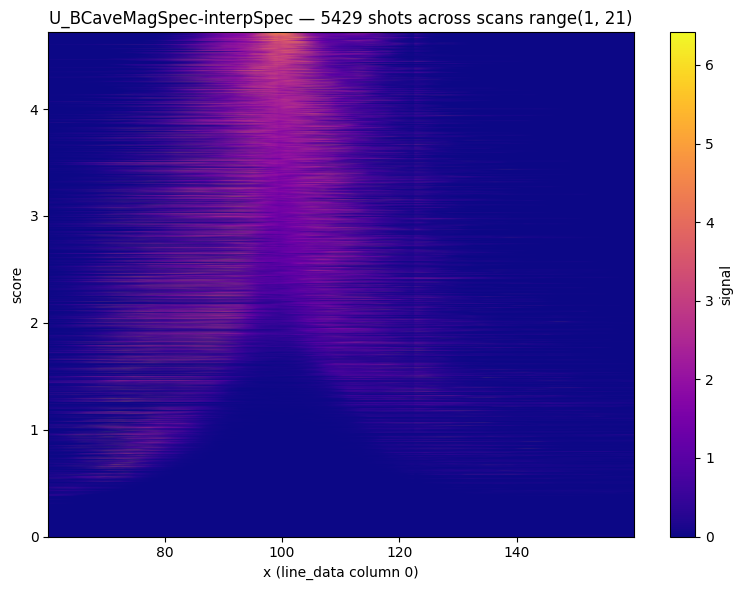

In [32]:
import matplotlib.pyplot as plt

# --- score every record with the currently defined score() ---
scored = [(r, score(r.x_axis, r.lineout)) for r in records]

# --- filter NaNs ---
valid = [(r, s) for r, s in scored if np.isfinite(s)]

# --- optional sigma clip on score; set to None to disable ---
SIGMA_CUT: Optional[float] = 6.0
if SIGMA_CUT is not None and len(valid) > 5:
    arr = np.array([s for _, s in valid])
    lo = arr.mean() - SIGMA_CUT * arr.std()
    hi = arr.mean() + SIGMA_CUT * arr.std()
    kept = [(r, s) for r, s in valid if lo <= s <= hi]
    dropped = len(valid) - len(kept)
    if dropped:
        print(f"sigma-cut dropped {dropped} shot(s) outside [{lo:.3g}, {hi:.3g}]")
    valid = kept

if not valid:
    raise RuntimeError("No valid shots to plot.")

# --- sort by score ---
valid.sort(key=lambda rs: rs[1])

# --- pad lineouts to a common length ---
max_len = max(r.lineout.size for r, _ in valid)
stacked = np.full((len(valid), max_len), np.nan, dtype=float)
for i, (r, _) in enumerate(valid):
    stacked[i, : r.lineout.size] = r.lineout

scores = np.array([s for _, s in valid])

# --- x-axis from the first valid record; assumes a shared grid ---
x_ref = valid[0][0].x_axis
if x_ref is not None:
    x_min, x_max = float(x_ref.min()), float(x_ref.max())
else:
    x_min, x_max = 0.0, float(max_len)

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(
    stacked,
    aspect="auto",
    origin="lower",
    cmap="plasma",
    extent=[x_min, x_max, scores.min(), scores.max()],
)
ax.set_xlabel("x (line_data column 0)")
ax.set_ylabel("score")
ax.set_title(
    f"{DEVICE_FOLDER} — {len(valid)} shots across {len(list(SCAN_NUMBERS))} scan(s)"
)
fig.colorbar(im, ax=ax, label="signal")
fig.tight_layout()
plt.show()

## Notes & next steps

**Alternative: load with the s-file DataFrame.** If you want to colour the waterfall by an s-file scalar (e.g. laser energy, ICT charge), load with `ScanData` and pass `stem_override` so the `<device>_expected_path` column resolves correctly:

```python
sd = ScanData.from_date(
    year=YEAR, month=MONTH, day=DAY, number=scan_number,
    experiment=EXPERIMENT,
    stem_override={DEVICE_FOLDER: DEVICE_FILE_STEM},
)
file_paths = sd.data_frame[f"{DEVICE_FOLDER}_expected_path"].tolist()
# join with sd.data_frame["U_BCaveICT charge"] or similar
```

**Promoting the scoring function.** If you converge on a single metric you want in production, the smallest principled promotion is extending `Array1DScanAnalyzer.waterfall_sort_key` in `ScanAnalysis` to accept a callable applied to `line_data` (today it only accepts an s-file column name). That keeps the function in the library but does not require any multi-scan abstraction — still single-scan, still YAML-configurable.

**Multi-scan as a library primitive.** If you find yourself running this multi-scan pattern often, the right home for a helper is `GEECS-Data-Utils`, not `ScanAnalysis` — something like `iter_shots_across_scans(scan_tags, device, *, device_file_stem=None, file_tail=...)` yielding `(tag, shot, file_path)` triples. That keeps the per-scan abstraction in `ScanAnalysis` clean and gives this notebook (and others) a one-line loader.